#**Imports**

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# Import the necessary libraries for model building, training, and visualization

import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import numpy as np


#**Settings and Data Collection**

In [ ]:
# Hyperparameters and configuration settings

#DATA_DIR = '/content/drive/MyDrive/mri_data'
DATA_DIR = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset") #For directly from kaggle
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 4

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


In [ ]:
import os

# List contents of the base data directory
print(f"Contents of {DATA_DIR}:")
print(os.listdir(DATA_DIR))

# List contents of Training and Testing directories to check class subfolders
print(f"\nContents of {DATA_DIR}/Training:")
print(os.listdir(DATA_DIR + '/Training'))

print(f"\nContents of {DATA_DIR}/Testing:")
print(os.listdir(DATA_DIR + '/Testing'))

Contents of /kaggle/input/brain-tumor-mri-dataset:
['Training', 'Testing']

Contents of /kaggle/input/brain-tumor-mri-dataset/Training:
['pituitary', 'notumor', 'meningioma', 'glioma']

Contents of /kaggle/input/brain-tumor-mri-dataset/Testing:
['pituitary', 'notumor', 'meningioma', 'glioma']


#**Image Processing & Split**

In [ ]:
# Image preprocessing: resize, convert to tensor, and normalize
# Edit: Changed to use transforms.v2
# Also added GrayScale, as the images are GrayScale

transform = transforms.Compose([
    v2.ToImage(),                           #Making sure it's represented as an image
    v2.Resize((IMG_SIZE, IMG_SIZE)),        #Resize the image
    v2.ToDtype(torch.float32, scale=True),  #Converts the values to float32
    v2.Grayscale(num_output_channels=1),    #Make sure there's no color, force 1 channel
    v2.Normalize([0.5], [0.5])
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Sets the device to cuda

In [ ]:
# Upload training and testing datasets from Google Drive / Kaggle

train_data = datasets.ImageFolder(root=DATA_DIR + '/Training', transform=transform)
test_data = datasets.ImageFolder(root=DATA_DIR + '/Testing', transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
#Basic look at the classes and training/testing split

print(train_data.classes)
print(len(train_data))
print(len(test_data))

['glioma', 'meningioma', 'notumor', 'pituitary']
5600
1600


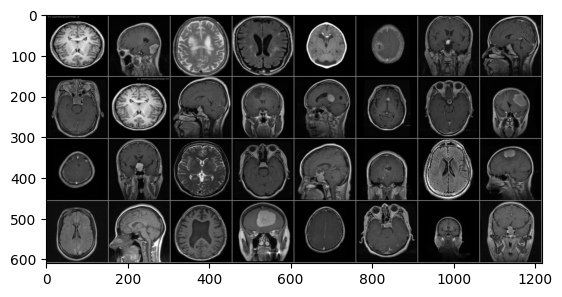

In [ ]:
#Sample of the images in the dataset

def show(img):
   img = img * 0.5 + 0.5
   img = img.clamp(0, 1)
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
   plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

show(make_grid(images))

#**Models**

In [ ]:
# Baseline MLP model: flattens the pixels of the image and passes them through fully connected layers of neurons

class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(IMG_SIZE * IMG_SIZE, 512)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(512, NUM_CLASSES)

  def forward(self,x):
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

In [ ]:
#CNN Model 1
#Two convolutions steps, with two pooling steps

class CNN1(nn.Module):
  def __init__(self):
    super().__init__()
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.flatten = nn.Flatten()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1)
    self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1)

    self.fc1 = nn.Linear(16 * 36 * 36, 512) #conv1: <128, 128, 1> => <126, 126, 8> pool1: <126, 126, 8> => <63, 63, 8> conv2: <63, 63, 8> => <61, 61, 16> pool2: <61, 61, 16> => <30, 30, 16> flattened: 30 * 30 * 16
    self.fc2 = nn.Linear(512, NUM_CLASSES)

  def forward(self, x):
    #Convolution Layer 1
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)

    #Convolution Layer 2
    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    #MLP
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

In [ ]:
#CNN Model 2
#Four convolution steps, with three pooling steps

class CNN2(nn.Module):
  def __init__(self):
    super().__init__()
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size=3, stride=3)
    self.flatten = nn.Flatten()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1)
    self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1)
    self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1)

    self.fc1 = nn.Linear(128 * 4 * 4, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 256)
    self.fc4 = nn.Linear(256, 128)
    self.fc5 = nn.Linear(128, 64)
    self.fc6 = nn.Linear(64, NUM_CLASSES)

  def forward(self, x):
    #Convolution Layer 1
    x = self.conv1(x)
    x = self.relu(x)

    #Convolution Layer 2
    x = self.conv2(x)
    x = self.relu(x)

    x = self.pool(x)

    #Convolution Layer 3
    x = self.conv3(x)
    x = self.relu(x)

    x = self.pool(x)

    #Convolution Layer 4
    x = self.conv4(x)
    x = self.relu(x)

    x = self.pool(x)

    #MLP
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    x = self.fc3(x)
    x = self.relu(x)
    x = self.fc4(x)
    x = self.relu(x)
    x = self.fc5(x)
    x = self.relu(x)
    x = self.fc6(x)
    return x


In [ ]:
#Class for Model creation and statistics

class CreateModel:
  def __init__(self, model, criterion, optimizer):
    self.model = model
    self.criterion = criterion
    self.optimizer = optimizer
    self.done = False
    self.history = {"loss": [], "train_accuracy": []}
    self.metrics = {}

  def __str__(self):
    return str(self.model)

  def run(self):
    self.model.train()

    for epoch in range(EPOCHS):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0

      for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

      epoch_loss = running_loss / len(train_loader)
      epoch_accuracy = correct / total
      self.history["loss"].append(epoch_loss)
      self.history["train_accuracy"].append(epoch_accuracy)
      print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}')

    self.done = True

  def summary(self, model_name=None):
    assert self.done, "Model not trained yet"

    self.model.eval()
    model_name = model_name or self.model.__class__.__name__

    all_preds = []
    all_labels = []

    with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = self.model(images)
          _, predicted = torch.max(outputs, 1)
          all_preds.extend(predicted.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

    report = classification_report(all_labels, all_preds, target_names=train_data.classes, digits=4, output_dict=True)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    confusion = confusion_matrix(all_labels, all_preds)

    self.metrics = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "report": report,
        "confusion_matrix": confusion
    }

    print(f'Performance summary for {model_name}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Macro F1: {macro_f1:.4f}')
    print(f'Weighted F1: {weighted_f1:.4f}\n')
    print(classification_report(all_labels, all_preds, target_names=train_data.classes, digits=4))
    class_names = train_data.classes
    class_precision = [report[name]['precision'] for name in class_names]
    class_recall = [report[name]['recall'] for name in class_names]
    class_f1 = [report[name]['f1-score'] for name in class_names]
    epochs = range(1, len(self.history['loss']) + 1)
    x = np.arange(len(class_names))
    width = 0.25

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{model_name} Evaluation Summary', fontsize=16)

    axes[0, 0].plot(epochs, self.history['loss'], marker='o', color='tab:blue')
    axes[0, 0].set_title('Training Loss by Epoch')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_xticks(list(epochs))
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(epochs, self.history['train_accuracy'], marker='o', color='tab:green')
    axes[0, 1].set_title('Training Accuracy by Epoch')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_ylim(0, 1.05)
    axes[0, 1].set_xticks(list(epochs))
    axes[0, 1].grid(alpha=0.3)

    im = axes[1, 0].imshow(confusion, cmap='Blues')
    axes[1, 0].set_title('Confusion Matrix')
    axes[1, 0].set_xlabel('Predicted Label')
    axes[1, 0].set_ylabel('True Label')
    axes[1, 0].set_xticks(np.arange(len(class_names)))
    axes[1, 0].set_yticks(np.arange(len(class_names)))
    axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1, 0].set_yticklabels(class_names)

    for i in range(len(class_names)):
      for j in range(len(class_names)):
        axes[1, 0].text(j, i, confusion[i, j], ha='center', va='center', color='black')

    fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

    axes[1, 1].bar(x - width, class_precision, width, label='Precision')
    axes[1, 1].bar(x, class_recall, width, label='Recall')
    axes[1, 1].bar(x + width, class_f1, width, label='F1-Score')
    axes[1, 1].set_title('Per-Class Metrics')
    axes[1, 1].set_xlabel('Class')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return self.metrics



#**Baseline Model Testing**

In [ ]:
#Baseline Testing
model = MLP().to(device)

# Define the loss function and optimizer for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Create Model
baseline = CreateModel(model, criterion, optimizer)
print(baseline)


MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=22500, out_features=512, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=512, out_features=4, bias=True)
)


In [ ]:
#Run the model
baseline.run()

Epoch 1/10, Loss: 1.5615, Train Accuracy: 0.6164
Epoch 2/10, Loss: 0.7196, Train Accuracy: 0.7139
Epoch 3/10, Loss: 0.5682, Train Accuracy: 0.7825
Epoch 4/10, Loss: 0.5354, Train Accuracy: 0.7909
Epoch 5/10, Loss: 0.5062, Train Accuracy: 0.8025
Epoch 6/10, Loss: 0.4611, Train Accuracy: 0.8246
Epoch 7/10, Loss: 0.3954, Train Accuracy: 0.8521
Epoch 8/10, Loss: 0.4140, Train Accuracy: 0.8368
Epoch 9/10, Loss: 0.3771, Train Accuracy: 0.8557
Epoch 10/10, Loss: 0.3566, Train Accuracy: 0.8579


Performance summary for Baseline MLP
Accuracy: 0.7769
Macro F1: 0.7731
Weighted F1: 0.7731

              precision    recall  f1-score   support

      glioma     0.8504    0.5400    0.6606       400
  meningioma     0.6245    0.8150    0.7072       400
     notumor     0.8337    0.9400    0.8837       400
   pituitary     0.8713    0.8125    0.8409       400

    accuracy                         0.7769      1600
   macro avg     0.7950    0.7769    0.7731      1600
weighted avg     0.7950    0.7769    0.7731      1600



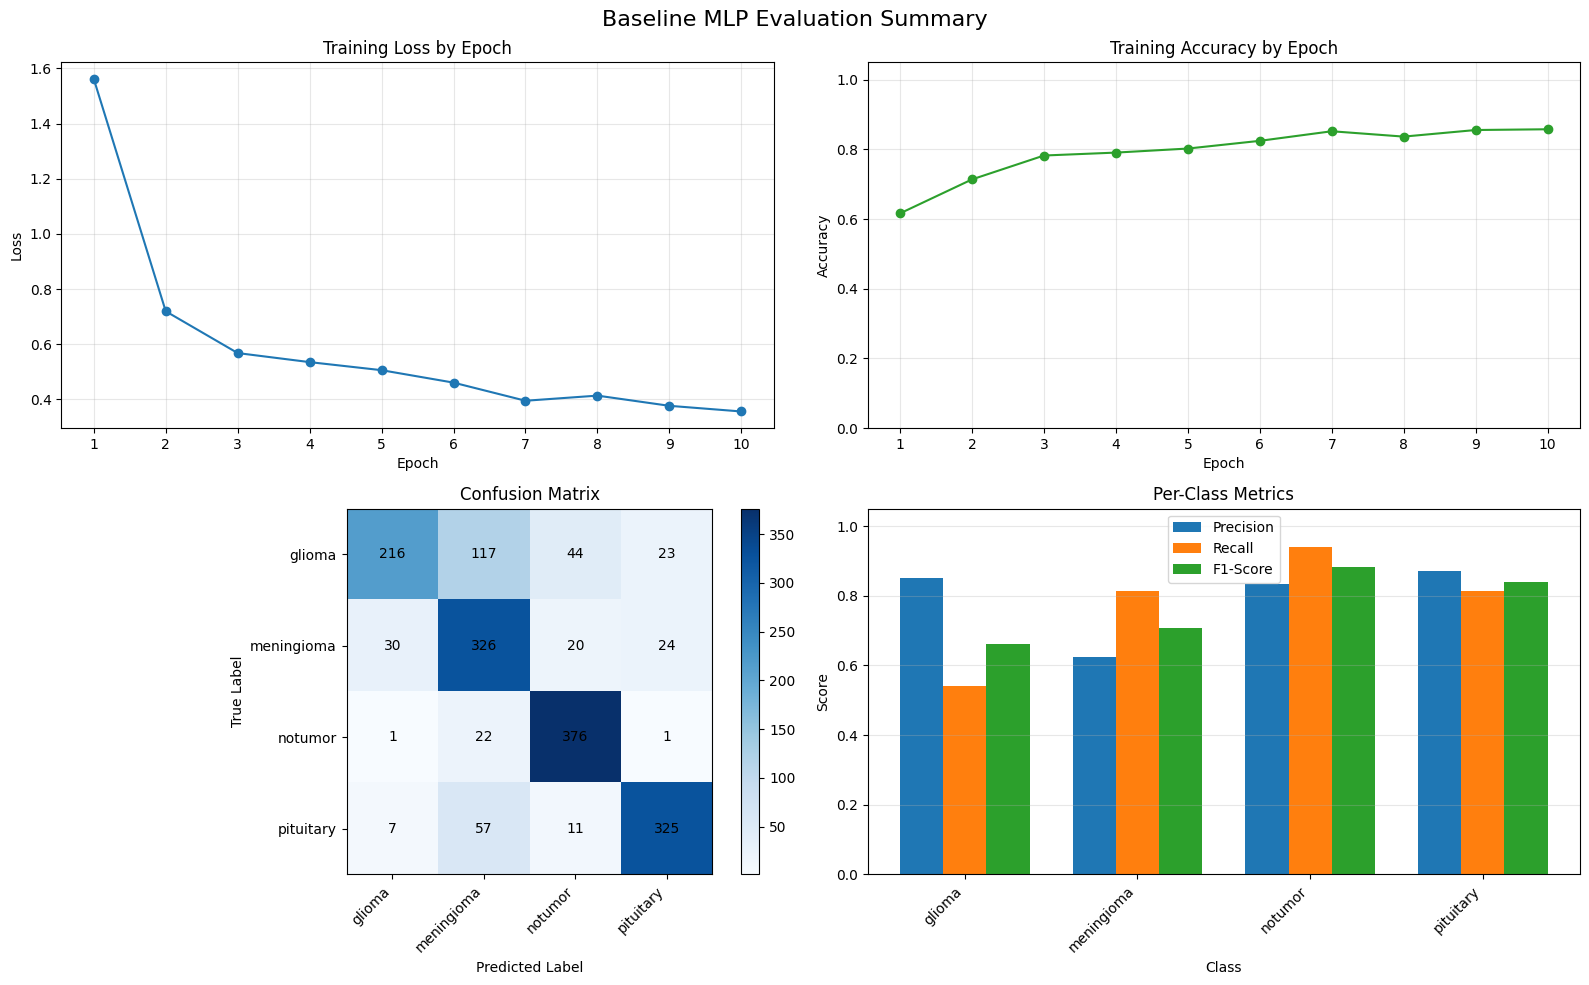

In [ ]:
#Get Summary
baseline_metrics = baseline.summary('Baseline MLP')

#**CNN1 Model Testing**

In [ ]:
#CNN1 Testing
model = CNN1().to(device)

# Define the loss function and optimizer for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Create Model
cnn1 = CreateModel(model, criterion, optimizer)
print(cnn1)

CNN1(
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=20736, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=4, bias=True)
)


In [ ]:
#Run the model
cnn1.run()

Epoch 1/10, Loss: 0.7035, Train Accuracy: 0.7204
Epoch 2/10, Loss: 0.3331, Train Accuracy: 0.8770
Epoch 3/10, Loss: 0.2015, Train Accuracy: 0.9271
Epoch 4/10, Loss: 0.1224, Train Accuracy: 0.9593
Epoch 5/10, Loss: 0.0843, Train Accuracy: 0.9727
Epoch 6/10, Loss: 0.0494, Train Accuracy: 0.9823
Epoch 7/10, Loss: 0.0333, Train Accuracy: 0.9893
Epoch 8/10, Loss: 0.0118, Train Accuracy: 0.9980
Epoch 9/10, Loss: 0.0059, Train Accuracy: 0.9989
Epoch 10/10, Loss: 0.0077, Train Accuracy: 0.9984


Performance summary for CNN Model 1
Accuracy: 0.8738
Macro F1: 0.8712
Weighted F1: 0.8712

              precision    recall  f1-score   support

      glioma     0.8987    0.6875    0.7790       400
  meningioma     0.7856    0.8975    0.8378       400
     notumor     0.8633    0.9950    0.9245       400
   pituitary     0.9734    0.9150    0.9433       400

    accuracy                         0.8738      1600
   macro avg     0.8802    0.8738    0.8712      1600
weighted avg     0.8802    0.8738    0.8712      1600



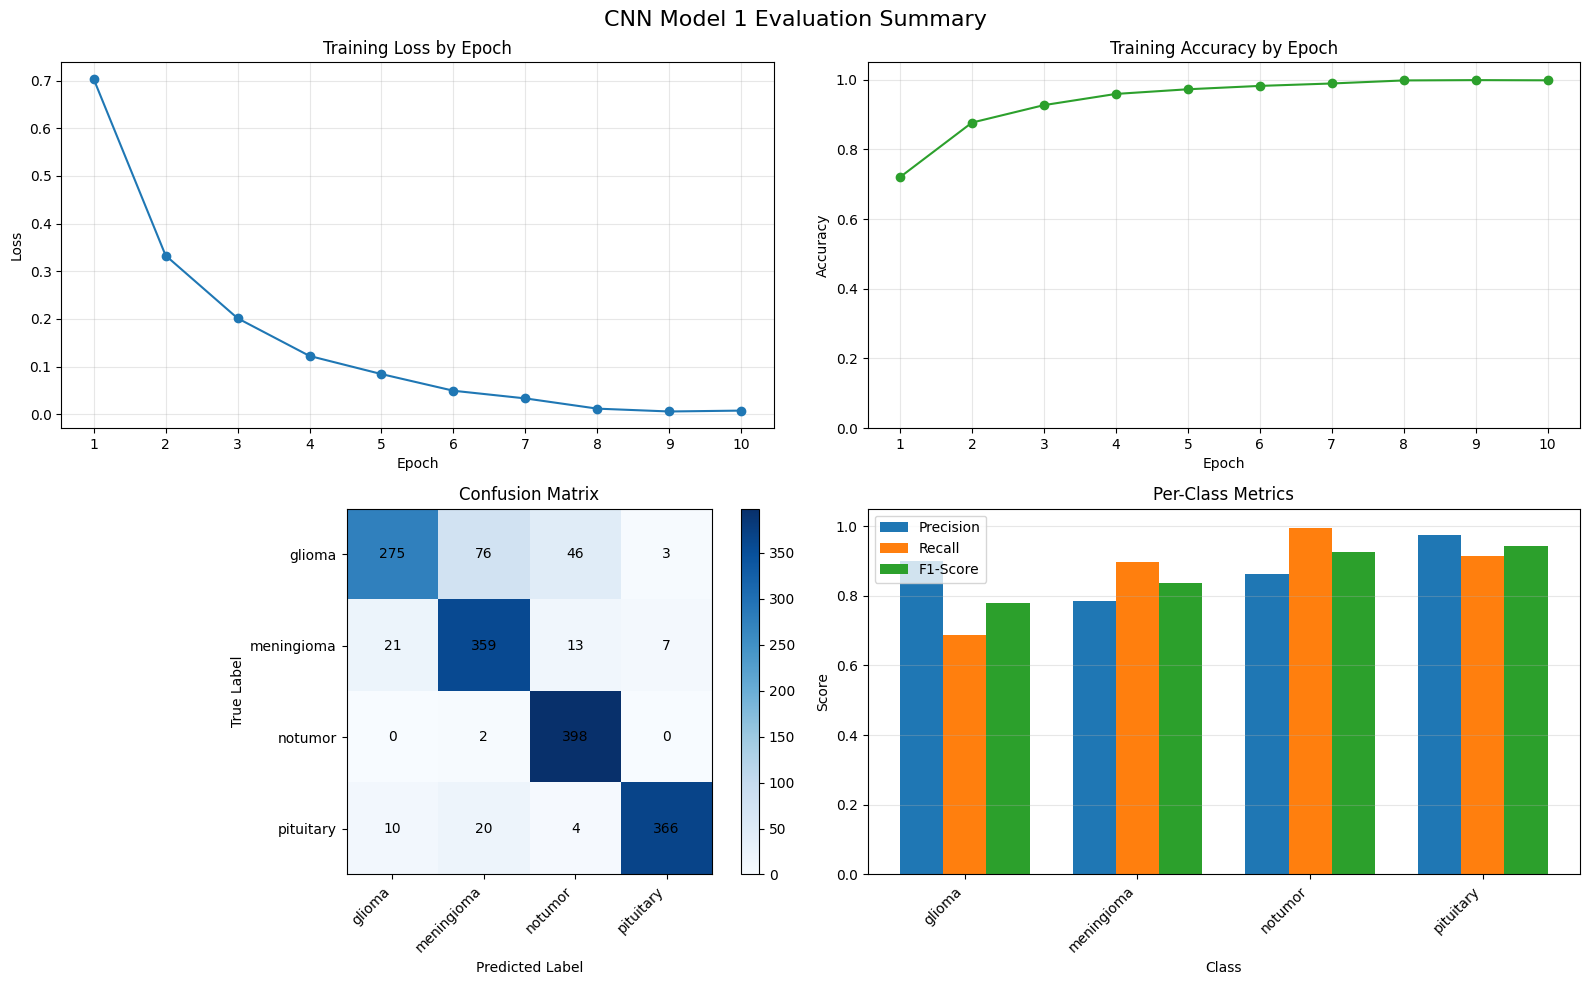

In [ ]:
#Get Summary
cnn1_metrics = cnn1.summary('CNN Model 1')

#**CNN2 Model Testing**

In [ ]:
#CNN2 Testing
model = CNN2().to(device)

# Define the loss function and optimizer for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#Create Model
cnn2 = CreateModel(model, criterion, optimizer)
print(cnn2)

CNN2(
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=64, bias=True)
  (fc6): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
#Run the model
cnn2.run()

Epoch 1/10, Loss: 1.1063, Train Accuracy: 0.4748
Epoch 2/10, Loss: 0.8619, Train Accuracy: 0.5971
Epoch 3/10, Loss: 0.5637, Train Accuracy: 0.7877
Epoch 4/10, Loss: 0.3900, Train Accuracy: 0.8564
Epoch 5/10, Loss: 0.3031, Train Accuracy: 0.8905
Epoch 6/10, Loss: 0.2354, Train Accuracy: 0.9137
Epoch 7/10, Loss: 0.1772, Train Accuracy: 0.9377
Epoch 8/10, Loss: 0.1258, Train Accuracy: 0.9564
Epoch 9/10, Loss: 0.1023, Train Accuracy: 0.9646
Epoch 10/10, Loss: 0.0929, Train Accuracy: 0.9714


Performance summary for CNN Model 2
Accuracy: 0.8962
Macro F1: 0.8946
Weighted F1: 0.8946

              precision    recall  f1-score   support

      glioma     0.8929    0.7500    0.8152       400
  meningioma     0.8278    0.9375    0.8792       400
     notumor     0.9048    0.9975    0.9489       400
   pituitary     0.9730    0.9000    0.9351       400

    accuracy                         0.8962      1600
   macro avg     0.8996    0.8962    0.8946      1600
weighted avg     0.8996    0.8962    0.8946      1600



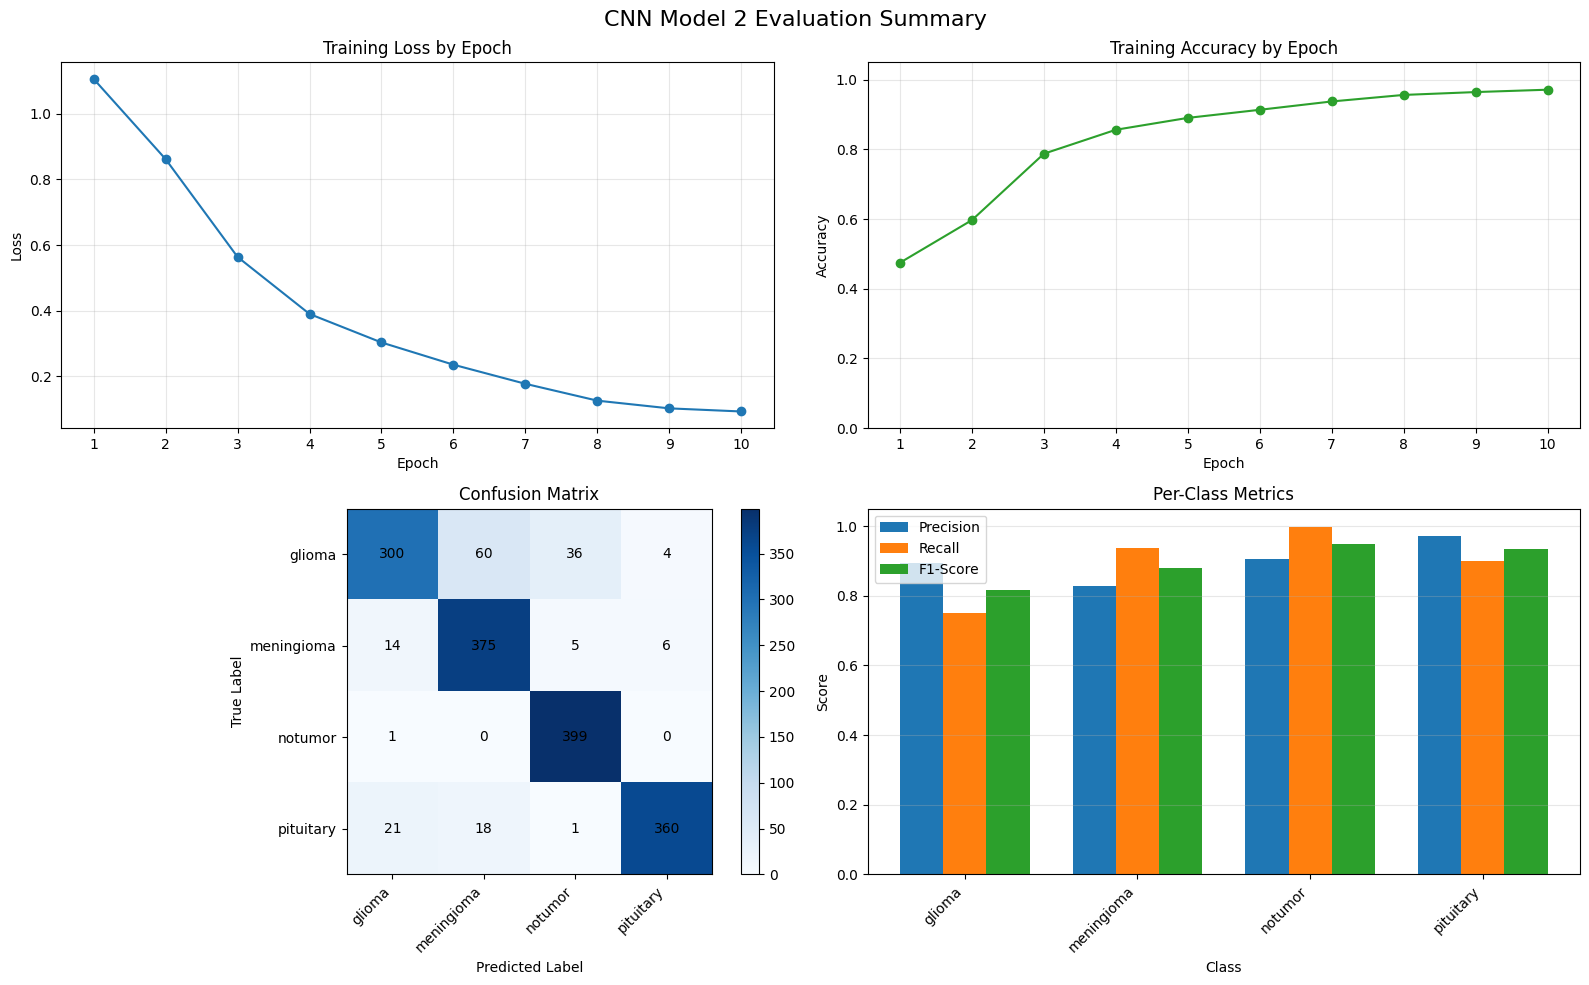

In [ ]:
#Get Summary
cnn2_metrics = cnn2.summary('CNN Model 2')

# **Model Comparison**

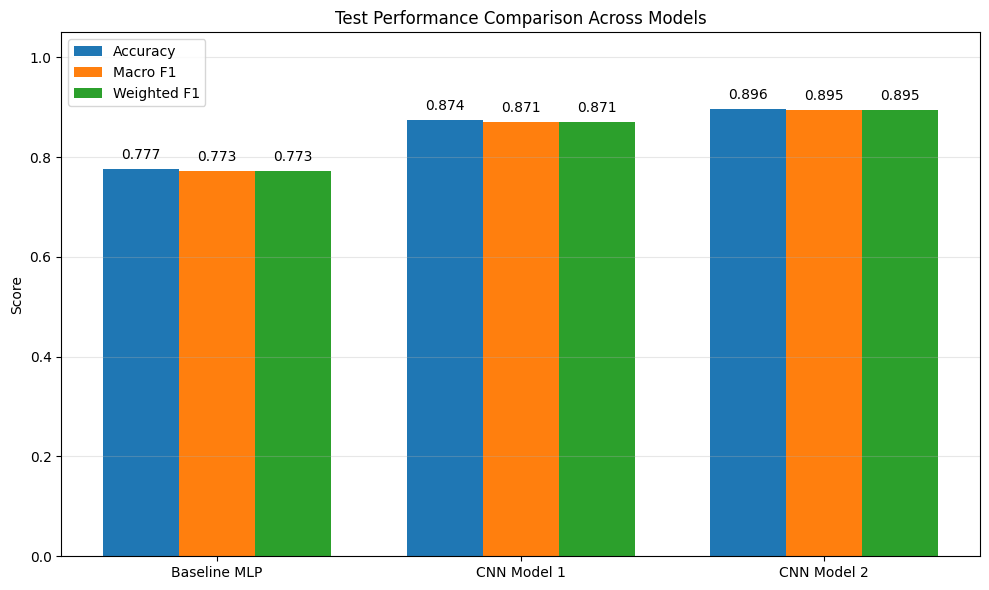

In [ ]:
# Compare the final test-set metrics side by side.

model_names = ['Baseline MLP', 'CNN Model 1', 'CNN Model 2']
accuracies = [baseline_metrics['accuracy'], cnn1_metrics['accuracy'], cnn2_metrics['accuracy']]
macro_f1_scores = [baseline_metrics['macro_f1'], cnn1_metrics['macro_f1'], cnn2_metrics['macro_f1']]
weighted_f1_scores = [baseline_metrics['weighted_f1'], cnn1_metrics['weighted_f1'], cnn2_metrics['weighted_f1']]

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, accuracies, width, label='Accuracy')
plt.bar(x, macro_f1_scores, width, label='Macro F1')
plt.bar(x + width, weighted_f1_scores, width, label='Weighted F1')
plt.xticks(x, model_names)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Test Performance Comparison Across Models')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for index, value in enumerate(accuracies):
    plt.text(index - width, value + 0.02, f'{value:.3f}', ha='center')
for index, value in enumerate(macro_f1_scores):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center')
for index, value in enumerate(weighted_f1_scores):
    plt.text(index + width, value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()
